Base model has 19 layers.

Model Summary (with frozen base and new head):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training the new 'head' only
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.9169 - loss: 0.4672 - val_accuracy: 0.9600 - val_loss: 0.2005
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9737 - loss: 0.1044 - val_accuracy: 0.9640 - val_loss: 0.1470
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9875 - loss: 0.0385 - val_accuracy: 0.9680 - val_loss: 0.1555
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.9877 - loss: 0.0332 - val_accuracy: 0.9660 - val_loss: 0.1743
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.9950 - loss: 0.0174 - val_accuracy: 0.9660 - val_loss: 0.1756

Evaluating on Test Set
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 424ms/step - accuracy: 0.9597 - loss: 0.1406
Test Accuracy: 96.40%


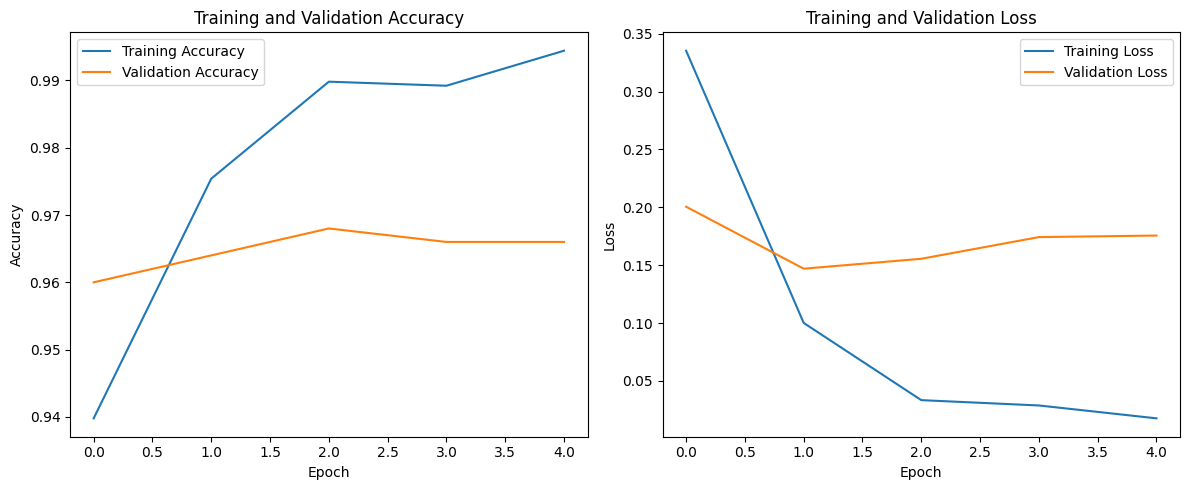

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

# cats vs dogs dataset
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=[
        'train[:5000]',      # 5000 images for training
        'train[5000:6000]',  # 1000 images for validation
        'train[6000:6500]'   # 500 images for testing
    ],
    with_info=True,
    as_supervised=True,
)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# create preprocessing functions

# resize all images to a standard size (150x150)
# apply the specific preprocessing required by VGG16
def format_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label

# apply preprocessing to our datasets
train_dataset = train_ds.map(format_image).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = val_ds.map(format_image).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_ds.map(format_image).batch(BATCH_SIZE)

# build model

# VGG16 base
base_model = tf.keras.applications.VGG16(
    input_shape=IMG_SIZE + (3,),
    include_top=False, # discard final classifier
    weights='imagenet' # weights pre-trained on ImageNet
)

# freeze the base
print(f"Base model has {len(base_model.layers)} layers.")
base_model.trainable = False

# add our new classifier "head"
inputs = keras.Input(shape=IMG_SIZE + (3,))

x = base_model(inputs, training=False) # only pass inputs to base model, don't train it

x = layers.GlobalAveragePooling2D()(x) # flatten output

x = layers.Dense(128, activation='relu')(x) # add our own classification layers
# o/p layer: 1 neuron (cat or dog) with sigmoid activation
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# compile model
# 'binary_crossentropy' for 2-class (cat/dog) classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary (with frozen base and new head):")
model.summary()

# train
print("\nTraining the new 'head' only")
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=validation_dataset
)

# evaluate
print("\nEvaluating on Test Set")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# graph
plt.figure(figsize=(12, 5))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()